# Chi-Square Test
**What is Chi-Square Test?**
Chi-Square Test is used to check whether there is a
significant relationship between two categorical variables.

**When to use Chi-Square Test?**
- Both variables are categorical
- Data is in the form of frequencies/counts
- Sample size is sufficiently large

**Types of Chi-Square Test:**
- Chi-Square Test of Independence → Relationship between 2 categorical variables
- Chi-Square Goodness of Fit      → Compare observed vs expected distribution

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, chisquare

## 1. Theory

**Hypothesis:**
- H0 (Null Hypothesis)      → The two variables are INDEPENDENT (no relationship)
- H1 (Alternate Hypothesis) → The two variables are DEPENDENT (relationship exists)

**Chi-Square Formula:**
χ² = Σ [ (O - E)² / E ]

Where:
- O = Observed Frequency
- E = Expected Frequency

**Degrees of Freedom (for Independence Test):**
df = (rows - 1) × (columns - 1)

**Decision Rule:**
- If p-value < 0.05 → Reject H0 → Significant relationship exists
- If p-value > 0.05 → Accept H0 → No significant relationship

## Dataset

A small survey of 20 people about their **Favorite Snack**
(Chips or Chocolate), split by **Gender**.

Simple enough to count by hand and verify the test.

In [2]:
data = {
    "Person" : [f"P{i+1}" for i in range(20)],
    "Gender" : ["Male", "Male", "Male", "Male", "Male",
                "Male", "Male", "Male", "Male", "Male",
                "Female", "Female", "Female", "Female", "Female",
                "Female", "Female", "Female", "Female", "Female"],
    "Snack"  : ["Chips", "Chips", "Chocolate", "Chips", "Chocolate",
                "Chips", "Chips", "Chocolate", "Chips", "Chips",
                "Chocolate", "Chocolate", "Chips", "Chocolate", "Chocolate",
                "Chocolate", "Chips", "Chocolate", "Chocolate", "Chocolate"]
}

df = pd.DataFrame(data)
print(df)

   Person  Gender      Snack
0      P1    Male      Chips
1      P2    Male      Chips
2      P3    Male  Chocolate
3      P4    Male      Chips
4      P5    Male  Chocolate
5      P6    Male      Chips
6      P7    Male      Chips
7      P8    Male  Chocolate
8      P9    Male      Chips
9     P10    Male      Chips
10    P11  Female  Chocolate
11    P12  Female  Chocolate
12    P13  Female      Chips
13    P14  Female  Chocolate
14    P15  Female  Chocolate
15    P16  Female  Chocolate
16    P17  Female      Chips
17    P18  Female  Chocolate
18    P19  Female  Chocolate
19    P20  Female  Chocolate


In [4]:
print("Male - Chips:", len(df[(df["Gender"]=="Male") & (df["Snack"]=="Chips")]))
print("Male - Chocolate:", len(df[(df["Gender"]=="Male") & (df["Snack"]=="Chocolate")]))
print("Female - Chips:", len(df[(df["Gender"]=="Female") & (df["Snack"]=="Chips")]))
print("Female - Chocolate:", len(df[(df["Gender"]=="Female") & (df["Snack"]=="Chocolate")]))

Male - Chips: 7
Male - Chocolate: 3
Female - Chips: 2
Female - Chocolate: 8


## 1. Chi-Square Test of Independence

**Question:**
Is there a relationship between Gender and Drink Preference?

**H0:** Gender and Drink Preference are INDEPENDENT
**H1:** Gender and Drink Preference are DEPENDENT

In [7]:
# Create Contingency Table
contingency_table = pd.crosstab(df["Gender"], df["Snack"])
print(contingency_table)

Snack   Chips  Chocolate
Gender                  
Female      2          8
Male        7          3


In [11]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-Value:", p)
print("Degrees of Freedom:", dof)

expected_df = pd.DataFrame(expected, columns=contingency_table.columns, index=contingency_table.index)
print("\nExpected Frequencies Table:")
print(expected_df)

Chi-Square Statistic: 3.2323232323232327
P-Value: 0.07219819770165818
Degrees of Freedom: 1

Expected Frequencies Table:
Snack   Chips  Chocolate
Gender                  
Female    4.5        5.5
Male      4.5        5.5


## Manual Calculation (For Understanding)

Let's manually verify one cell using the formula:
χ² contribution = (O - E)² / E

In [17]:
observed = contingency_table.values
expected = expected_df.values

chi2_contribution = (observed - expected)**2 / expected
print(chi2_contribution)

manual_chi2 = chi2_contribution.sum().sum()
print("\nManual Chi-Square Statistic:", manual_chi2)

print("\nScipy Chi-Square Statistic:", chi2)

if p < 0.05:
    print("Reject H0")
else:
    print("Accept H0")

[[1.38888889 1.13636364]
 [1.38888889 1.13636364]]

Manual Chi-Square Statistic: 5.05050505050505

Scipy Chi-Square Statistic: 3.2323232323232327
Accept H0


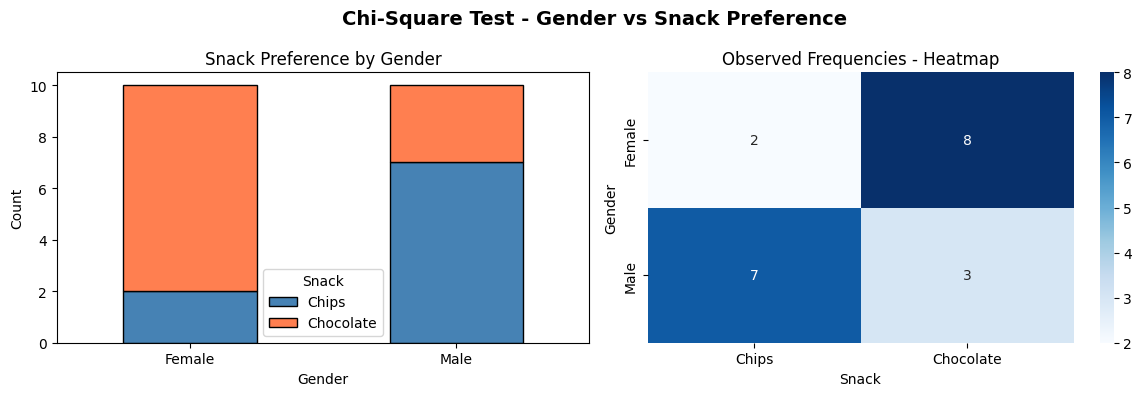

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Stacked Bar Chart
contingency_table.plot(kind="bar", stacked=True,
                        color=["steelblue", "coral", "green"],
                        edgecolor="black", ax=axes[0])
axes[0].set_title("Snack Preference by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Snack")

# Heatmap of Observed Frequencies
sns.heatmap(contingency_table, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Observed Frequencies - Heatmap")

plt.suptitle("Chi-Square Test - Gender vs Snack Preference", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Chi-Square Goodness of Fit Test

**Question:**
A dice is rolled 60 times. Is the dice fair?
(Expected: each face should appear 10 times)

**H0:** Dice is fair (observed = expected distribution)
**H1:** Dice is NOT fair (observed ≠ expected distribution)

In [21]:
# Self made dataset → dice roll results
faces    = [1, 2, 3, 4, 5, 6]
observed_rolls = [8, 12, 9, 14, 7, 10]   # Total = 60
expected_rolls = [10, 10, 10, 10, 10, 10] # Fair dice expectation

print("Face :", faces)
print("Observed Rolls :", observed_rolls)
print("Expected Rolls :", expected_rolls)
print("Total Rolls :", sum(observed_rolls))

Face : [1, 2, 3, 4, 5, 6]
Observed Rolls : [8, 12, 9, 14, 7, 10]
Expected Rolls : [10, 10, 10, 10, 10, 10]
Total Rolls : 60


In [24]:
chi2_stat, p  = chisquare(observed_rolls, expected_rolls)

print("Chi-Square Statistic:", chi2_stat)
print("P-Value:", p)

if p < 0.05:
    print("Reject H0")
else:
    print("Accept H0")

Chi-Square Statistic: 3.4
P-Value: 0.6385699231037951
Accept H0


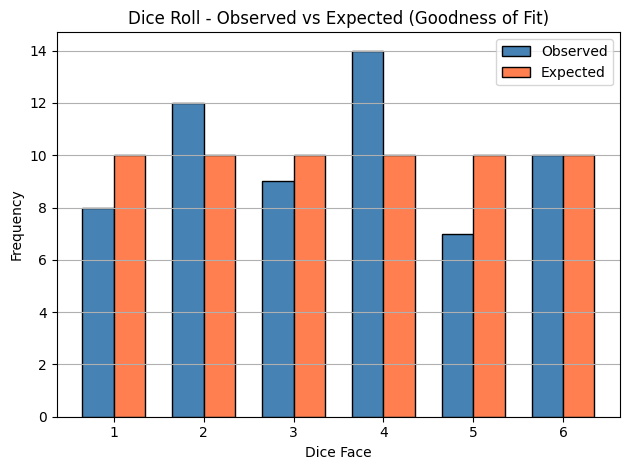

In [25]:
x = np.arange(len(faces))
width = 0.35

plt.bar(x - width/2, observed_rolls, width, label="Observed", color="steelblue", edgecolor="black")
plt.bar(x + width/2, expected_rolls, width, label="Expected", color="coral",     edgecolor="black")

plt.title("Dice Roll - Observed vs Expected (Goodness of Fit)")
plt.xlabel("Dice Face")
plt.ylabel("Frequency")
plt.xticks(x, faces)
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## Conclusion

In this notebook I covered:

- What is Chi-Square Test and When to use it
- Hypothesis (H0 and H1)
- Chi-Square Formula and Degrees of Freedom
- Chi-Square Test of Independence (Self Made - Gender vs Drink)
- Manual Chi-Square Calculation
- Chi-Square Goodness of Fit (Self Made - Dice Roll)
- Visualizations